# IMU / OptiTrack Sync Notebook

This notebook aligns the ankle IMU (`LOG00006.CSV`) and the OptiTrack marker file (`Take 2026-03-24 05.20.13 PM.csv`) by using the first foot swing.

It also handles the marker ID handoff from `C7D50` to `C7D60` by stitching both IDs into one continuous ankle track and correcting the position offset at the handoff.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from scipy.signal import correlate

sys.path.insert(0, '/home/user/soccer_analysis/pyshoe_CSH')
from motion_segments import add_motion_plane_kinematics, extract_motion_segments

plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = Path('/home/user/soccer_analysis/data/optitrack_imu/0324_17_20')
IMU_PATH = DATA_DIR / 'LOG00006.CSV'
OPTI_PATH = DATA_DIR / 'Take 2026-03-24 05.20.13 PM.csv'

MARKER_IDS = ['C7D50', 'C7D60']

IMU_BASELINE_SEC = 0.5
OPTI_BASELINE_SEC = 1.0
SEARCH_WINDOW_SEC = 8.0
IMU_ROLLING_SAMPLES = 11
OPTI_ROLLING_SAMPLES = 7
THRESHOLD_N_MAD = 8.0
REFINE_WINDOW_SEC = (-0.6, 2.0)
MAX_REFINE_SHIFT_SEC = 1.0
LAG_WINDOW_SEC = 12.0
LAG_STEP_SEC = 10.0
LAG_MAX_SHIFT_SEC = 1.5
LINEAR_FIT_METHOD = 'global'  # 'first_last', 'global', 'weighted', or 'none'
SEGMENT_TIME_COLUMN = 'time_synced_to_imu'
SEGMENT_POS_SMOOTH_SAMPLES = 241
SEGMENT_VEL_SMOOTH_SAMPLES = 121
SEGMENT_MIN_SPEED_MPS = 0.08
SEGMENT_MIN_DURATION_SEC = 3.0
SEGMENT_OUTPUT_DIR = DATA_DIR / 'straight_walk_segments'


def safe_zscore(values):
    values = np.asarray(values, dtype=float)
    mean = np.nanmean(values)
    std = np.nanstd(values)
    if not np.isfinite(std) or std == 0:
        return np.zeros_like(values, dtype=float)
    return (values - mean) / std


def mad_threshold(signal, baseline_mask, n_mad=8.0):
    baseline = pd.Series(signal, dtype=float).loc[baseline_mask].dropna()
    if baseline.empty:
        raise RuntimeError('Baseline window is empty. Check the input signal.')
    center = baseline.median()
    mad = (baseline - center).abs().median()
    robust_scale = 1.4826 * mad
    if not np.isfinite(robust_scale) or robust_scale == 0:
        robust_scale = baseline.std()
    if not np.isfinite(robust_scale) or robust_scale == 0:
        robust_scale = 1e-6
    return center + n_mad * robust_scale


def first_contiguous_crossing(time_s, signal, baseline_end_s, search_end_s, n_mad=8.0, min_run=3):
    time_s = np.asarray(time_s, dtype=float)
    signal = pd.Series(signal, dtype=float)
    threshold = mad_threshold(signal, time_s <= baseline_end_s, n_mad=n_mad)
    mask = (time_s <= search_end_s) & signal.gt(threshold).fillna(False).to_numpy()
    idx = np.flatnonzero(mask)
    if len(idx) == 0:
        raise RuntimeError('No onset was found. Lower THRESHOLD_N_MAD or increase SEARCH_WINDOW_SEC.')

    run_start = idx[0]
    prev = idx[0]
    for current in idx[1:]:
        if current == prev + 1:
            prev = current
            continue
        if prev - run_start + 1 >= min_run:
            return int(run_start), float(threshold)
        run_start = current
        prev = current

    if prev - run_start + 1 >= min_run:
        return int(run_start), float(threshold)
    return int(idx[0]), float(threshold)


def extract_marker_xyz(opti_raw, marker_id):
    marker_cols = [
        col
        for col in opti_raw.columns
        if len(col) >= 5 and col[2] == marker_id and col[-1] in ['X', 'Y', 'Z']
    ]
    if len(marker_cols) != 3:
        raise ValueError(f'Could not find X/Y/Z columns for marker ID {marker_id}.')
    xyz = opti_raw[marker_cols].apply(pd.to_numeric, errors='coerce').copy()
    xyz.columns = ['X', 'Y', 'Z']
    return xyz


def estimate_translation(prev_track, next_track):
    prev_valid = prev_track.notna().all(axis=1)
    next_valid = next_track.notna().all(axis=1)
    overlap = prev_valid & next_valid

    if overlap.any():
        delta = (
            prev_track.loc[overlap, ['X', 'Y', 'Z']].to_numpy()
            - next_track.loc[overlap, ['X', 'Y', 'Z']].to_numpy()
        )
        return np.nanmedian(delta, axis=0), int(overlap.sum())

    prev_idx = np.flatnonzero(prev_valid.to_numpy())
    next_idx = np.flatnonzero(next_valid.to_numpy())
    if len(prev_idx) == 0 or len(next_idx) == 0:
        return np.zeros(3), 0

    delta = (
        prev_track.loc[prev_idx[-1], ['X', 'Y', 'Z']].to_numpy()
        - next_track.loc[next_idx[0], ['X', 'Y', 'Z']].to_numpy()
    )
    return delta, 0


def load_imu(path):
    imu = pd.read_csv(path)
    imu['imu_time'] = imu['timestamp'] - imu['timestamp'].iloc[0]
    imu['acc_norm'] = np.sqrt((imu[['AccX', 'AccY', 'AccZ']] ** 2).sum(axis=1))
    imu['gyro_norm'] = np.sqrt((imu[['GyroX', 'GyroY', 'GyroZ']] ** 2).sum(axis=1))

    baseline = imu.loc[imu['imu_time'] <= IMU_BASELINE_SEC, 'acc_norm']
    gravity_level = baseline.median()
    imu['imu_sync_signal'] = (imu['acc_norm'] - gravity_level).abs().rolling(
        IMU_ROLLING_SAMPLES, center=True, min_periods=1
    ).mean()
    return imu


def load_optitrack_ankle(path, marker_ids):
    opti_raw = pd.read_csv(path, header=[1, 2, 3, 4, 5])
    frame_col = opti_raw.columns[0]
    time_col = opti_raw.columns[1]

    merged = pd.DataFrame({
        'frame': pd.to_numeric(opti_raw[frame_col], errors='coerce'),
        'opti_time': pd.to_numeric(opti_raw[time_col], errors='coerce'),
    })

    raw_tracks = {marker_id: extract_marker_xyz(opti_raw, marker_id) for marker_id in marker_ids}
    shifted_tracks = {}
    switch_log = []
    cumulative_offset = np.zeros(3)
    prev_shifted = None

    for i, marker_id in enumerate(marker_ids):
        raw_track = raw_tracks[marker_id]
        if i == 0:
            shifted_track = raw_track.copy()
        else:
            delta_mm, overlap_count = estimate_translation(prev_shifted, raw_track)
            cumulative_offset = cumulative_offset + delta_mm
            shifted_track = raw_track.add(pd.Series(cumulative_offset, index=['X', 'Y', 'Z']), axis=1)

            first_valid = np.flatnonzero(raw_track.notna().all(axis=1).to_numpy())
            first_frame = int(merged.loc[first_valid[0], 'frame']) if len(first_valid) else None
            switch_log.append({
                'from_marker': marker_ids[i - 1],
                'to_marker': marker_id,
                'first_new_frame': first_frame,
                'overlap_frames': int(overlap_count),
                'applied_offset_mm': cumulative_offset.copy(),
            })

        shifted_tracks[marker_id] = shifted_track
        prev_shifted = shifted_track

        for axis in ['X', 'Y', 'Z']:
            merged[f'{marker_id}_{axis}'] = shifted_track[axis]

    valid_by_marker = pd.DataFrame({
        marker_id: raw_tracks[marker_id].notna().all(axis=1) for marker_id in marker_ids
    })

    def pick_source(row):
        for marker_id in marker_ids:
            if bool(row[marker_id]):
                return marker_id
        return None

    merged['marker_source'] = valid_by_marker.apply(pick_source, axis=1)

    for axis in ['X', 'Y', 'Z']:
        axis_stack = pd.concat([shifted_tracks[marker_id][axis] for marker_id in marker_ids], axis=1)
        merged[axis] = axis_stack.bfill(axis=1).iloc[:, 0]

    merged[['X', 'Y', 'Z']] = merged[['X', 'Y', 'Z']].interpolate(limit_direction='both')
    dt = merged['opti_time'].diff().replace(0, np.nan)
    velocity = merged[['X', 'Y', 'Z']].diff().div(1000.0).div(dt, axis=0)
    merged['ankle_speed_mps'] = np.sqrt((velocity ** 2).sum(axis=1)).rolling(
        OPTI_ROLLING_SAMPLES, center=True, min_periods=1
    ).mean()
    merged['opti_sync_signal'] = merged['ankle_speed_mps'].diff().div(dt).abs().rolling(
        OPTI_ROLLING_SAMPLES, center=True, min_periods=1
    ).mean()

    return merged, raw_tracks, shifted_tracks, switch_log


def refine_offset_seconds(
    imu_time,
    imu_signal,
    opti_time,
    opti_signal,
    coarse_offset_sec,
    center_time_sec,
    window_sec=(-0.6, 2.0),
    max_shift_sec=1.0,
):
    imu_time = np.asarray(imu_time, dtype=float)
    imu_signal = np.asarray(imu_signal, dtype=float)
    opti_time = np.asarray(opti_time, dtype=float) + coarse_offset_sec
    opti_signal = np.asarray(opti_signal, dtype=float)

    interpolated = np.interp(imu_time, opti_time, opti_signal, left=np.nan, right=np.nan)
    mask = (
        (imu_time >= center_time_sec + window_sec[0])
        & (imu_time <= center_time_sec + window_sec[1])
        & np.isfinite(interpolated)
    )

    if mask.sum() < 10:
        return 0.0

    x = safe_zscore(imu_signal[mask])
    y = safe_zscore(interpolated[mask])
    cc = correlate(x, y, mode='full')
    lags = np.arange(-len(y) + 1, len(x))
    dt = np.nanmedian(np.diff(imu_time[mask]))
    lag_sec = lags * dt
    valid = np.abs(lag_sec) <= max_shift_sec
    return float(lag_sec[valid][np.argmax(cc[valid])])


def overlap_corr(x, y):
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() < 2:
        return np.nan
    return float(np.corrcoef(x[valid], y[valid])[0, 1])


def estimate_local_lags(
    imu_time,
    imu_signal,
    opti_time,
    opti_signal,
    window_sec=12.0,
    step_sec=10.0,
    max_shift_sec=1.5,
):
    imu_time = np.asarray(imu_time, dtype=float)
    imu_signal = np.asarray(imu_signal, dtype=float)
    opti_time = np.asarray(opti_time, dtype=float)
    opti_signal = np.asarray(opti_signal, dtype=float)

    common_start = max(float(np.nanmin(imu_time)), float(np.nanmin(opti_time)))
    common_end = min(float(np.nanmax(imu_time)), float(np.nanmax(opti_time)))
    rows = []
    current_start = common_start

    while current_start + window_sec <= common_end:
        current_end = current_start + window_sec
        center = current_start + 0.5 * window_sec
        imu_mask = (imu_time >= current_start) & (imu_time <= current_end)
        t = imu_time[imu_mask]
        x = imu_signal[imu_mask]
        y = np.interp(t, opti_time, opti_signal, left=np.nan, right=np.nan)
        valid = np.isfinite(y)
        t = t[valid]
        x = x[valid]
        y = y[valid]

        if len(t) < 20:
            current_start += step_sec
            continue

        xz = safe_zscore(x)
        yz = safe_zscore(y)
        cc = correlate(xz, yz, mode='full')
        lags = np.arange(-len(yz) + 1, len(xz))
        dt = np.nanmedian(np.diff(t))
        lag_sec = lags * dt
        keep = np.abs(lag_sec) <= max_shift_sec
        if not np.any(keep):
            current_start += step_sec
            continue

        best_lag_sec = float(lag_sec[keep][np.argmax(cc[keep])])
        rows.append({
            'window_start_s': float(current_start),
            'window_end_s': float(current_end),
            'center_time_s': float(center),
            'residual_lag_sec': best_lag_sec,
            'corr': overlap_corr(xz, yz),
            'n_samples': int(len(t)),
        })
        current_start += step_sec

    return pd.DataFrame(rows)


def fit_linear_lag_model(local_lag_df, method='global'):
    if local_lag_df.empty:
        return 0.0, 0.0

    x = local_lag_df['center_time_s'].to_numpy(dtype=float)
    y = local_lag_df['residual_lag_sec'].to_numpy(dtype=float)

    if method in [None, 'none']:
        return 0.0, 0.0
    if method == 'first_last':
        slope, intercept = np.polyfit([x[0], x[-1]], [y[0], y[-1]], 1)
    elif method == 'weighted':
        weights = np.clip(local_lag_df['corr'].fillna(0).to_numpy(dtype=float), 0.01, None)
        slope, intercept = np.polyfit(x, y, 1, w=weights)
    elif method == 'global':
        slope, intercept = np.polyfit(x, y, 1)
    else:
        raise ValueError(f'Unknown LINEAR_FIT_METHOD: {method}')

    return float(slope), float(intercept)


def apply_linear_lag_model(opti_time, slope_sec_per_sec, intercept_sec):
    opti_time = np.asarray(opti_time, dtype=float)
    lag_correction = slope_sec_per_sec * opti_time + intercept_sec
    return opti_time + lag_correction


def add_corridor_kinematics(
    opti_df,
    time_col='time_synced_to_imu',
    pos_smooth_samples=241,
    vel_smooth_samples=121,
    orient_first_segment_positive=True,
    orientation_threshold_mps=0.05,
):
    out = opti_df.copy()
    xyz = out[['X', 'Y', 'Z']].to_numpy(dtype=float)
    center = np.nanmean(xyz, axis=0)
    xyz0 = xyz - center
    _, _, vt = np.linalg.svd(xyz0, full_matrices=False)
    axis = vt[0].copy()
    projection_mm = xyz0 @ axis
    time_s = out[time_col].to_numpy(dtype=float)
    projection_smooth_mm = pd.Series(projection_mm).rolling(
        pos_smooth_samples, center=True, min_periods=1
    ).mean().to_numpy()
    corridor_vel_mps = np.gradient(projection_smooth_mm, time_s) / 1000.0
    corridor_vel_smooth_mps = pd.Series(corridor_vel_mps).rolling(
        vel_smooth_samples, center=True, min_periods=1
    ).mean().to_numpy()

    if orient_first_segment_positive:
        first_idx = np.flatnonzero(np.abs(corridor_vel_smooth_mps) > orientation_threshold_mps)
        if len(first_idx) and corridor_vel_smooth_mps[first_idx[0]] < 0:
            axis = -axis
            projection_mm = -projection_mm
            projection_smooth_mm = -projection_smooth_mm
            corridor_vel_mps = -corridor_vel_mps
            corridor_vel_smooth_mps = -corridor_vel_smooth_mps

    out['corridor_pos_mm'] = projection_mm
    out['corridor_pos_smooth_mm'] = projection_smooth_mm
    out['corridor_vel_mps'] = corridor_vel_mps
    out['corridor_vel_smooth_mps'] = corridor_vel_smooth_mps
    out['corridor_axis_x'] = axis[0]
    out['corridor_axis_y'] = axis[1]
    out['corridor_axis_z'] = axis[2]
    out['corridor_center_x'] = center[0]
    out['corridor_center_y'] = center[1]
    out['corridor_center_z'] = center[2]
    return out, axis, center


def extract_straight_walk_segments(
    opti_df,
    time_col='time_synced_to_imu',
    corridor_vel_col='corridor_vel_smooth_mps',
    min_abs_corridor_vel_mps=0.08,
    min_duration_sec=3.0,
):
    active = np.abs(opti_df[corridor_vel_col].to_numpy(dtype=float)) > float(min_abs_corridor_vel_mps)
    change = np.diff(np.r_[False, active, False].astype(int))
    starts = np.where(change == 1)[0]
    ends = np.where(change == -1)[0] - 1
    rows = []

    for segment_id, (start_idx, end_idx) in enumerate(zip(starts, ends), start=1):
        start_time_s = float(opti_df.iloc[start_idx][time_col])
        end_time_s = float(opti_df.iloc[end_idx][time_col])
        duration_sec = end_time_s - start_time_s
        if duration_sec < min_duration_sec:
            continue

        median_corridor_vel = float(np.nanmedian(opti_df.iloc[start_idx : end_idx + 1][corridor_vel_col]))
        direction_sign = int(np.sign(median_corridor_vel))
        direction_label = 'positive' if direction_sign >= 0 else 'negative'
        corridor_distance_m = float(
            (opti_df.iloc[end_idx]['corridor_pos_smooth_mm'] - opti_df.iloc[start_idx]['corridor_pos_smooth_mm']) / 1000.0
        )

        rows.append({
            'segment_id': len(rows) + 1,
            'direction_sign': direction_sign,
            'direction_label': direction_label,
            'start_idx': int(start_idx),
            'end_idx': int(end_idx),
            'start_frame': int(opti_df.iloc[start_idx]['frame']),
            'end_frame': int(opti_df.iloc[end_idx]['frame']),
            'start_time_s': start_time_s,
            'end_time_s': end_time_s,
            'duration_sec': duration_sec,
            'median_corridor_vel_mps': median_corridor_vel,
            'corridor_distance_m': corridor_distance_m,
        })

    return pd.DataFrame(rows)


In [2]:
imu = load_imu(IMU_PATH)
opti_ankle, raw_tracks, shifted_tracks, switch_log = load_optitrack_ankle(OPTI_PATH, MARKER_IDS)

imu_onset_idx, imu_threshold = first_contiguous_crossing(
    imu['imu_time'].to_numpy(),
    imu['imu_sync_signal'],
    baseline_end_s=IMU_BASELINE_SEC,
    search_end_s=SEARCH_WINDOW_SEC,
    n_mad=THRESHOLD_N_MAD,
)

opti_onset_idx, opti_threshold = first_contiguous_crossing(
    opti_ankle['opti_time'].to_numpy(),
    opti_ankle['opti_sync_signal'],
    baseline_end_s=OPTI_BASELINE_SEC,
    search_end_s=SEARCH_WINDOW_SEC,
    n_mad=THRESHOLD_N_MAD,
)

coarse_offset_sec = float(imu.loc[imu_onset_idx, 'imu_time'] - opti_ankle.loc[opti_onset_idx, 'opti_time'])
refine_offset_sec = refine_offset_seconds(
    imu['imu_time'].to_numpy(),
    imu['imu_sync_signal'].to_numpy(),
    opti_ankle['opti_time'].to_numpy(),
    opti_ankle['opti_sync_signal'].fillna(0).to_numpy(),
    coarse_offset_sec=coarse_offset_sec,
    center_time_sec=float(imu.loc[imu_onset_idx, 'imu_time']),
    window_sec=REFINE_WINDOW_SEC,
    max_shift_sec=MAX_REFINE_SHIFT_SEC,
)

offset_opti_to_imu_sec = coarse_offset_sec + refine_offset_sec
opti_ankle['time_synced_const'] = opti_ankle['opti_time'] + offset_opti_to_imu_sec

local_lag_df = estimate_local_lags(
    imu['imu_time'].to_numpy(),
    imu['imu_sync_signal'].to_numpy(),
    opti_ankle['time_synced_const'].to_numpy(),
    opti_ankle['opti_sync_signal'].fillna(0).to_numpy(),
    window_sec=LAG_WINDOW_SEC,
    step_sec=LAG_STEP_SEC,
    max_shift_sec=LAG_MAX_SHIFT_SEC,
)
drift_slope_sec_per_sec, drift_intercept_sec = fit_linear_lag_model(local_lag_df, method=LINEAR_FIT_METHOD)

opti_ankle['time_synced_linear'] = apply_linear_lag_model(
    opti_ankle['time_synced_const'].to_numpy(),
    drift_slope_sec_per_sec,
    drift_intercept_sec,
)
opti_ankle['time_synced_to_imu'] = opti_ankle['time_synced_linear']

local_lag_df_linear = estimate_local_lags(
    imu['imu_time'].to_numpy(),
    imu['imu_sync_signal'].to_numpy(),
    opti_ankle['time_synced_linear'].to_numpy(),
    opti_ankle['opti_sync_signal'].fillna(0).to_numpy(),
    window_sec=LAG_WINDOW_SEC,
    step_sec=LAG_STEP_SEC,
    max_shift_sec=LAG_MAX_SHIFT_SEC,
)

opti_ankle, corridor_axis, corridor_center = add_corridor_kinematics(
    opti_ankle,
    time_col=SEGMENT_TIME_COLUMN,
    pos_smooth_samples=SEGMENT_POS_SMOOTH_SAMPLES,
    vel_smooth_samples=SEGMENT_VEL_SMOOTH_SAMPLES,
)
opti_ankle, motion_plane_axes, motion_plane_normal, motion_plane_center = add_motion_plane_kinematics(
    opti_ankle,
    time_col=SEGMENT_TIME_COLUMN,
    pos_smooth_samples=SEGMENT_POS_SMOOTH_SAMPLES,
    vel_smooth_samples=SEGMENT_VEL_SMOOTH_SAMPLES,
    speed_threshold_mps=SEGMENT_MIN_SPEED_MPS,
)
segment_summary_df = extract_motion_segments(
    opti_ankle,
    time_col=SEGMENT_TIME_COLUMN,
    speed_col='motion_plane_speed_smooth_mps',
    pos_cols=('motion_plane_u_smooth_mm', 'motion_plane_v_smooth_mm'),
    min_speed_mps=SEGMENT_MIN_SPEED_MPS,
    min_duration_sec=SEGMENT_MIN_DURATION_SEC,
)

for df in [opti_ankle, imu]:
    df['motion_segment_id'] = 0
    df['motion_direction_sign'] = 0
    df['motion_direction_label'] = 'none'
    df['motion_primary_axis_id'] = 0

opti_ankle['straight_segment_id'] = 0
opti_ankle['straight_direction_sign'] = 0
opti_ankle['straight_direction_label'] = 'none'
imu['straight_segment_id'] = 0
imu['straight_direction_sign'] = 0
imu['straight_direction_label'] = 'none'

for segment in segment_summary_df.itertuples(index=False):
    opti_mask = (
        (opti_ankle[SEGMENT_TIME_COLUMN] >= segment.start_time_s)
        & (opti_ankle[SEGMENT_TIME_COLUMN] <= segment.end_time_s)
    )
    imu_mask = (
        (imu['imu_time'] >= segment.start_time_s)
        & (imu['imu_time'] <= segment.end_time_s)
    )
    opti_ankle.loc[opti_mask, 'motion_segment_id'] = int(segment.segment_id)
    opti_ankle.loc[opti_mask, 'motion_direction_sign'] = int(segment.direction_sign)
    opti_ankle.loc[opti_mask, 'motion_direction_label'] = segment.direction_label
    opti_ankle.loc[opti_mask, 'motion_primary_axis_id'] = int(segment.primary_axis_id)
    imu.loc[imu_mask, 'motion_segment_id'] = int(segment.segment_id)
    imu.loc[imu_mask, 'motion_direction_sign'] = int(segment.direction_sign)
    imu.loc[imu_mask, 'motion_direction_label'] = segment.direction_label
    imu.loc[imu_mask, 'motion_primary_axis_id'] = int(segment.primary_axis_id)
    opti_ankle.loc[opti_mask, 'straight_segment_id'] = int(segment.segment_id)
    opti_ankle.loc[opti_mask, 'straight_direction_sign'] = int(segment.direction_sign)
    opti_ankle.loc[opti_mask, 'straight_direction_label'] = segment.direction_label
    imu.loc[imu_mask, 'straight_segment_id'] = int(segment.segment_id)
    imu.loc[imu_mask, 'straight_direction_sign'] = int(segment.direction_sign)
    imu.loc[imu_mask, 'straight_direction_label'] = segment.direction_label

summary = {
    'imu_onset_time_s': float(imu.loc[imu_onset_idx, 'imu_time']),
    'opti_onset_time_s': float(opti_ankle.loc[opti_onset_idx, 'opti_time']),
    'coarse_offset_opti_to_imu_s': coarse_offset_sec,
    'refine_offset_s': refine_offset_sec,
    'constant_offset_opti_to_imu_s': offset_opti_to_imu_sec,
    'linear_fit_method': LINEAR_FIT_METHOD,
    'linear_drift_slope_sec_per_sec': drift_slope_sec_per_sec,
    'linear_drift_intercept_sec': drift_intercept_sec,
    'linear_time_scale': 1.0 + drift_slope_sec_per_sec,
    'residual_lag_first_window_before_s': float(local_lag_df['residual_lag_sec'].iloc[0]) if not local_lag_df.empty else np.nan,
    'residual_lag_last_window_before_s': float(local_lag_df['residual_lag_sec'].iloc[-1]) if not local_lag_df.empty else np.nan,
    'residual_lag_first_window_after_s': float(local_lag_df_linear['residual_lag_sec'].iloc[0]) if not local_lag_df_linear.empty else np.nan,
    'residual_lag_last_window_after_s': float(local_lag_df_linear['residual_lag_sec'].iloc[-1]) if not local_lag_df_linear.empty else np.nan,
    'segment_method': 'motion_plane',
    'n_motion_segments': int(len(segment_summary_df)),
    'n_straight_walk_segments': int(len(segment_summary_df)),
    'segment_min_speed_mps': float(SEGMENT_MIN_SPEED_MPS),
    'segment_min_duration_sec': float(SEGMENT_MIN_DURATION_SEC),
}

for key, value in summary.items():
    if isinstance(value, (int, float, np.floating)):
        print(f'{key:>35}: {float(value):.6f}')
    else:
        print(f'{key:>35}: {value}')

print('\nLinear drift model')
print(f'  method: {LINEAR_FIT_METHOD}')
print(f'  residual_lag_sec = {drift_slope_sec_per_sec:.6f} * t + {drift_intercept_sec:.6f}')
print(f'  corrected_time = {(1.0 + drift_slope_sec_per_sec):.6f} * time_synced_const + {drift_intercept_sec:.6f}')
print('\nMotion plane axes (OptiTrack XYZ basis)')
print(f'  axis_1 = [{motion_plane_axes[0, 0]:.6f}, {motion_plane_axes[0, 1]:.6f}, {motion_plane_axes[0, 2]:.6f}]')
print(f'  axis_2 = [{motion_plane_axes[1, 0]:.6f}, {motion_plane_axes[1, 1]:.6f}, {motion_plane_axes[1, 2]:.6f}]')
print(f'  normal = [{motion_plane_normal[0]:.6f}, {motion_plane_normal[1]:.6f}, {motion_plane_normal[2]:.6f}]')
print(f'  center = [{motion_plane_center[0]:.3f}, {motion_plane_center[1]:.3f}, {motion_plane_center[2]:.3f}]')
print('\nLocal lag before linear correction')
print(local_lag_df[['center_time_s', 'residual_lag_sec', 'corr']].to_string(index=False))
print('\nLocal lag after linear correction')
print(local_lag_df_linear[['center_time_s', 'residual_lag_sec', 'corr']].to_string(index=False))
print('\nMotion segments')
print(segment_summary_df[['segment_id', 'direction_label', 'primary_axis_id', 'heading_deg', 'start_time_s', 'end_time_s', 'duration_sec', 'segment_distance_m']].to_string(index=False))

if switch_log:
    print('\nMarker handoff correction')
    for item in switch_log:
        from_marker = item['from_marker']
        to_marker = item['to_marker']
        first_new_frame = item['first_new_frame']
        overlap_frames = item['overlap_frames']
        dx, dy, dz = item['applied_offset_mm']
        print(
            f'  {from_marker} -> {to_marker} at frame {first_new_frame} | '
            f'overlap={overlap_frames} | applied shift [mm]=({dx:.3f}, {dy:.3f}, {dz:.3f})'
        )

source_changes = opti_ankle.loc[
    opti_ankle['marker_source'].ne(opti_ankle['marker_source'].shift())
    & opti_ankle['marker_source'].notna(),
    ['frame', 'opti_time', 'marker_source'],
]
print('\nMarker source changes')
print(source_changes.head(10).to_string(index=False))

if switch_log:
    first_new_frame = switch_log[0]['first_new_frame']
    handoff_view = opti_ankle.loc[
        opti_ankle['frame'].between(first_new_frame - 3, first_new_frame + 3),
        ['frame', 'opti_time', 'marker_source', 'X', 'Y', 'Z', 'ankle_speed_mps'],
    ]
    print('\nMerged track around the handoff')
    print(handoff_view.to_string(index=False))


                   imu_onset_time_s: 2.200000
                  opti_onset_time_s: 2.508333
        coarse_offset_opti_to_imu_s: -0.308333
                    refine_offset_s: 0.020000
      constant_offset_opti_to_imu_s: -0.288333
                  linear_fit_method: global
     linear_drift_slope_sec_per_sec: -0.000441
         linear_drift_intercept_sec: -0.009663
                  linear_time_scale: 0.999559
 residual_lag_first_window_before_s: -0.010000
  residual_lag_last_window_before_s: -0.140000
  residual_lag_first_window_after_s: 0.000000
   residual_lag_last_window_after_s: -0.020000
                     segment_method: motion_plane
                  n_motion_segments: 29.000000
           n_straight_walk_segments: 29.000000
              segment_min_speed_mps: 0.080000
           segment_min_duration_sec: 3.000000

Linear drift model
  method: global
  residual_lag_sec = -0.000441 * t + -0.009663
  corrected_time = 0.999559 * time_synced_const + -0.009663

Motion plane axe

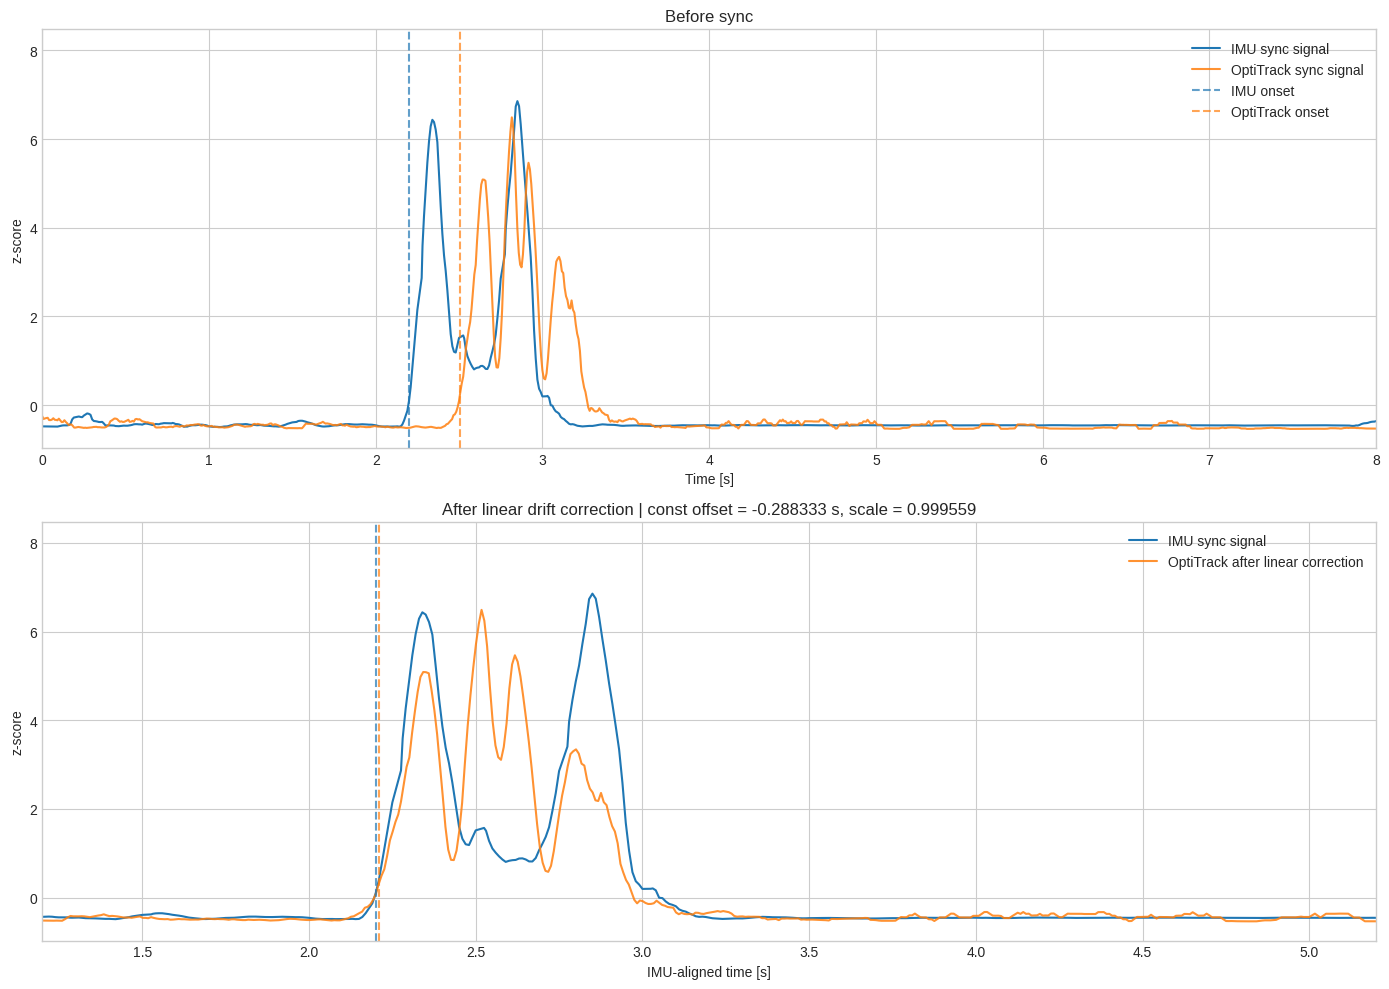

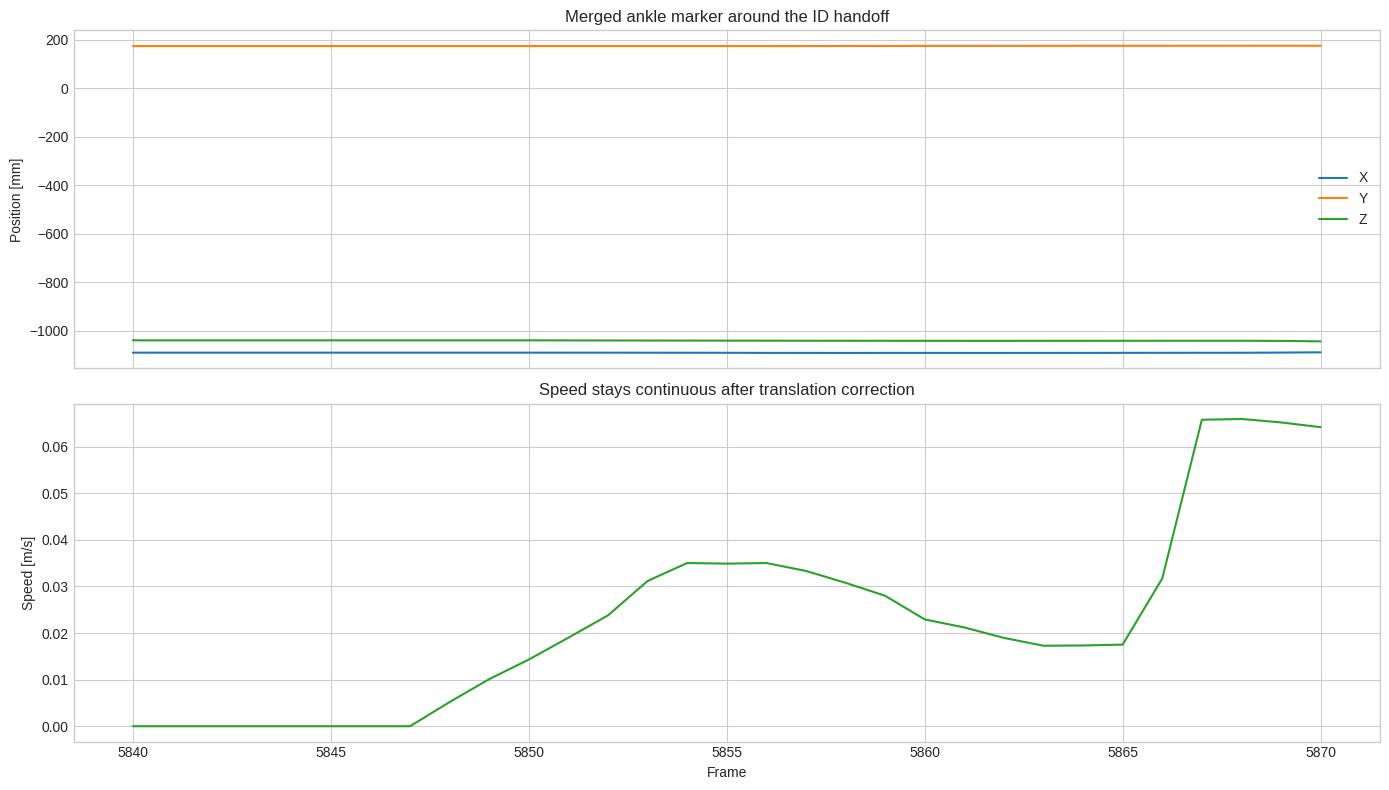

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(imu['imu_time'], safe_zscore(imu['imu_sync_signal']), label='IMU sync signal', linewidth=1.5)
axes[0].plot(
    opti_ankle['opti_time'],
    safe_zscore(opti_ankle['opti_sync_signal']),
    label='OptiTrack sync signal',
    linewidth=1.5,
    alpha=0.85,
)
axes[0].axvline(imu.loc[imu_onset_idx, 'imu_time'], color='tab:blue', linestyle='--', alpha=0.7, label='IMU onset')
axes[0].axvline(
    opti_ankle.loc[opti_onset_idx, 'opti_time'],
    color='tab:orange',
    linestyle='--',
    alpha=0.7,
    label='OptiTrack onset',
)
axes[0].set_xlim(0, SEARCH_WINDOW_SEC)
axes[0].set_title('Before sync')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('z-score')
axes[0].legend(loc='upper right')

axes[1].plot(imu['imu_time'], safe_zscore(imu['imu_sync_signal']), label='IMU sync signal', linewidth=1.5)
axes[1].plot(
    opti_ankle['time_synced_to_imu'],
    safe_zscore(opti_ankle['opti_sync_signal']),
    label='OptiTrack after linear correction',
    linewidth=1.5,
    alpha=0.85,
)
axes[1].axvline(imu.loc[imu_onset_idx, 'imu_time'], color='tab:blue', linestyle='--', alpha=0.7)
axes[1].axvline(opti_ankle.loc[opti_onset_idx, 'time_synced_to_imu'], color='tab:orange', linestyle='--', alpha=0.7)
axes[1].set_xlim(max(0, float(imu.loc[imu_onset_idx, 'imu_time']) - 1.0), float(imu.loc[imu_onset_idx, 'imu_time']) + 3.0)
axes[1].set_title(
    f'After linear drift correction | const offset = {offset_opti_to_imu_sec:.6f} s, scale = {1.0 + drift_slope_sec_per_sec:.6f}'
)
axes[1].set_xlabel('IMU-aligned time [s]')
axes[1].set_ylabel('z-score')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

if switch_log:
    first_new_frame = switch_log[0]['first_new_frame']
    handoff_mask = opti_ankle['frame'].between(first_new_frame - 10, first_new_frame + 20)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    for axis_name in ['X', 'Y', 'Z']:
        axes[0].plot(opti_ankle.loc[handoff_mask, 'frame'], opti_ankle.loc[handoff_mask, axis_name], label=axis_name)
    axes[0].set_title('Merged ankle marker around the ID handoff')
    axes[0].set_ylabel('Position [mm]')
    axes[0].legend(loc='best')

    axes[1].plot(opti_ankle.loc[handoff_mask, 'frame'], opti_ankle.loc[handoff_mask, 'ankle_speed_mps'], color='tab:green')
    axes[1].set_ylabel('Speed [m/s]')
    axes[1].set_xlabel('Frame')
    axes[1].set_title('Speed stays continuous after translation correction')

    plt.tight_layout()
    plt.show()


Common overlap on IMU timeline: 0.000 s to 256.406 s
Full-trial correlation before sync:          0.3728
Full-trial correlation after constant shift: 0.7163
Full-trial correlation after linear sync:    0.8870
Marker handoff on IMU timeline:              48.431 s


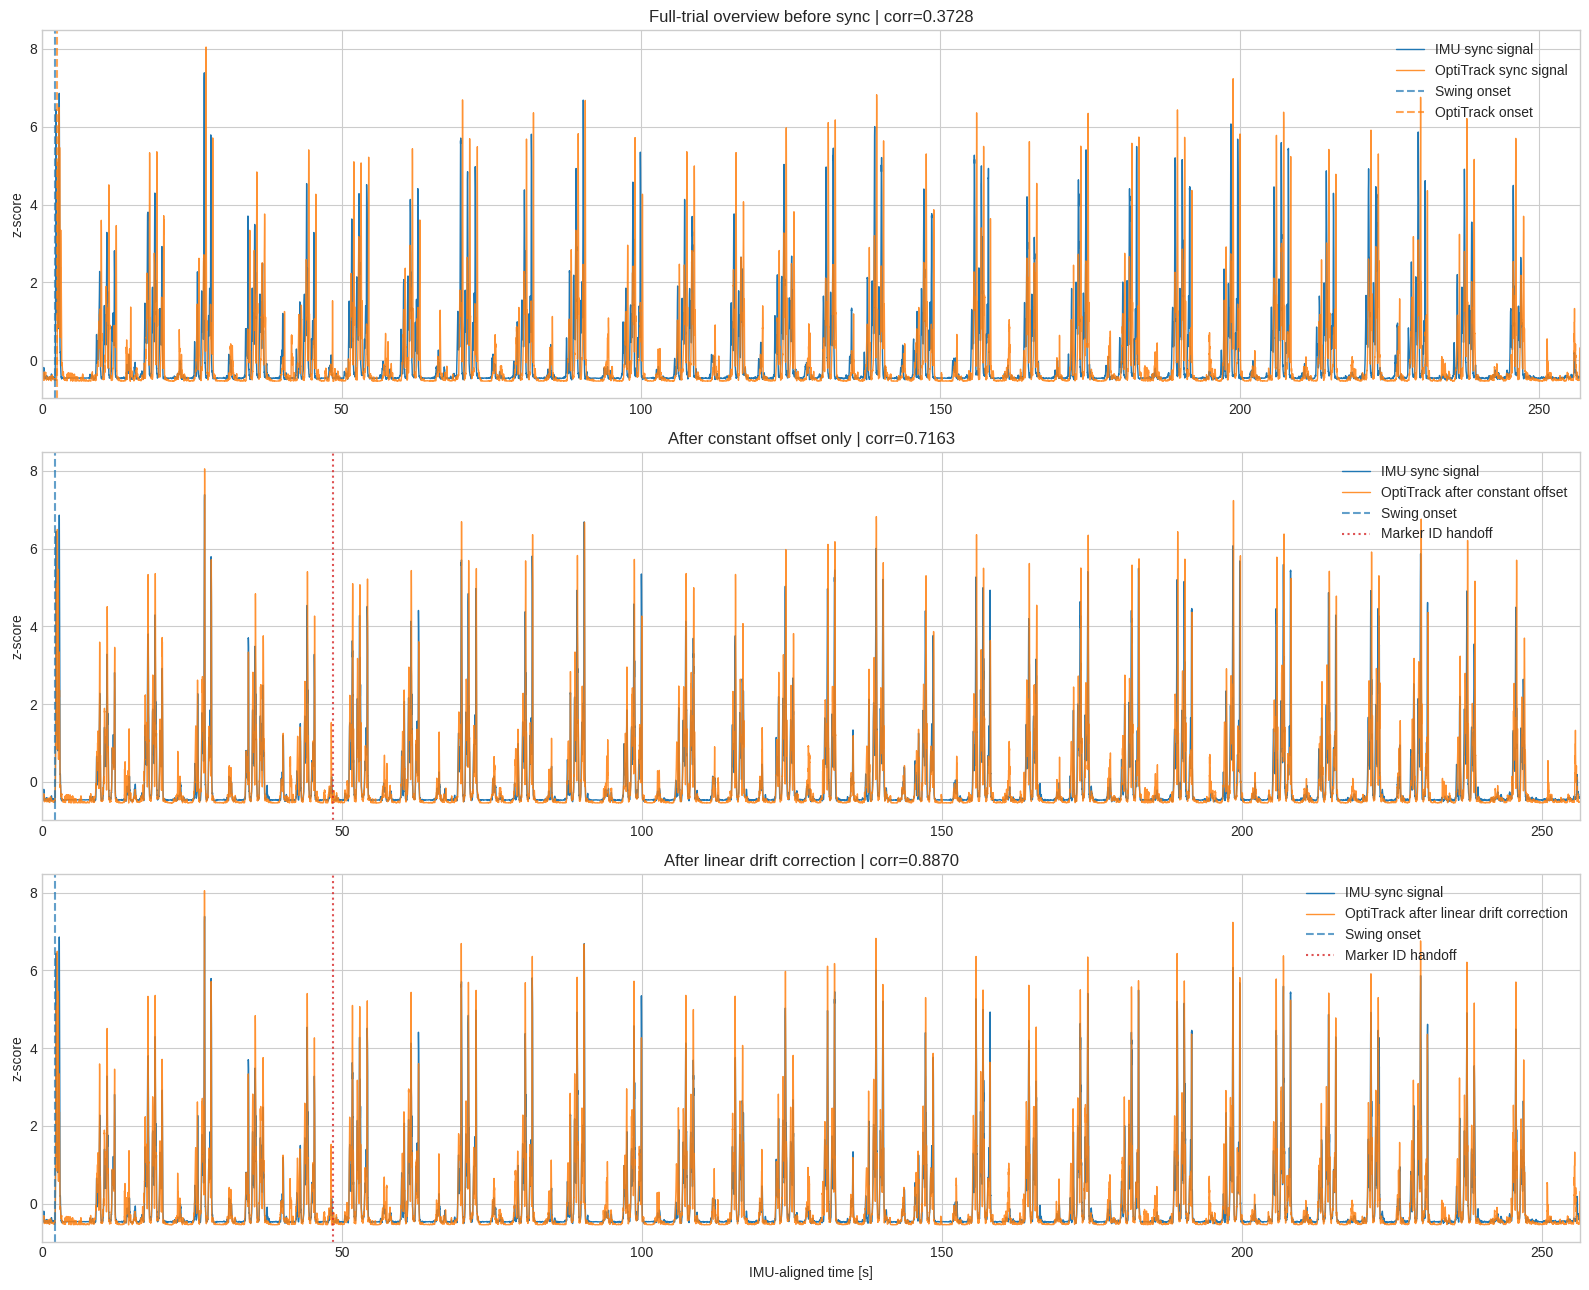

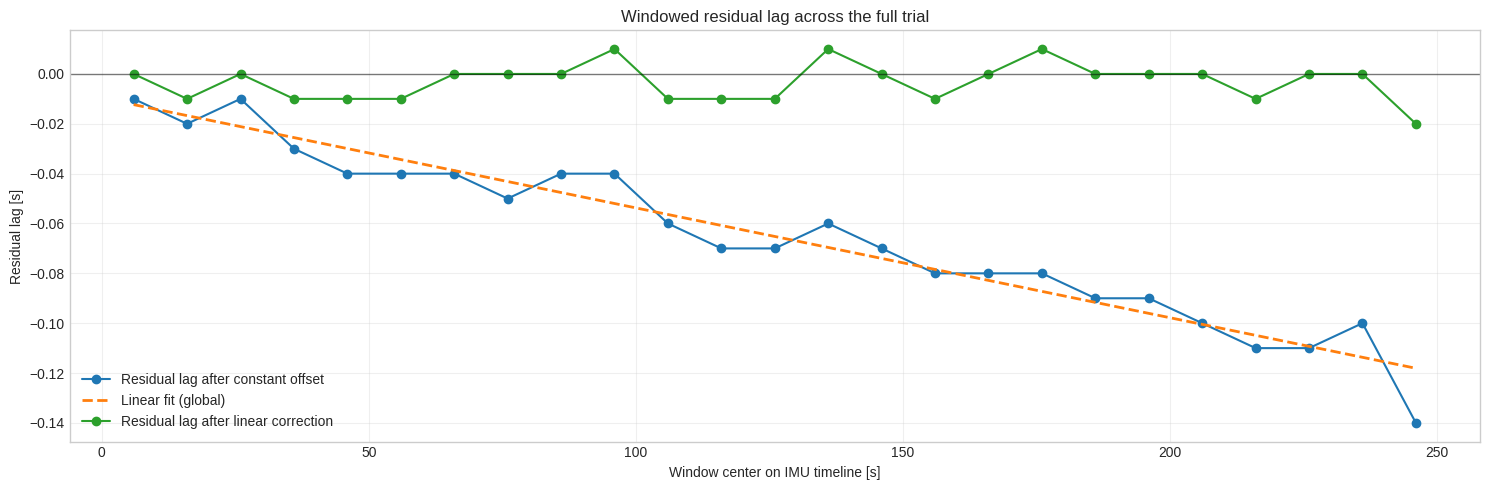

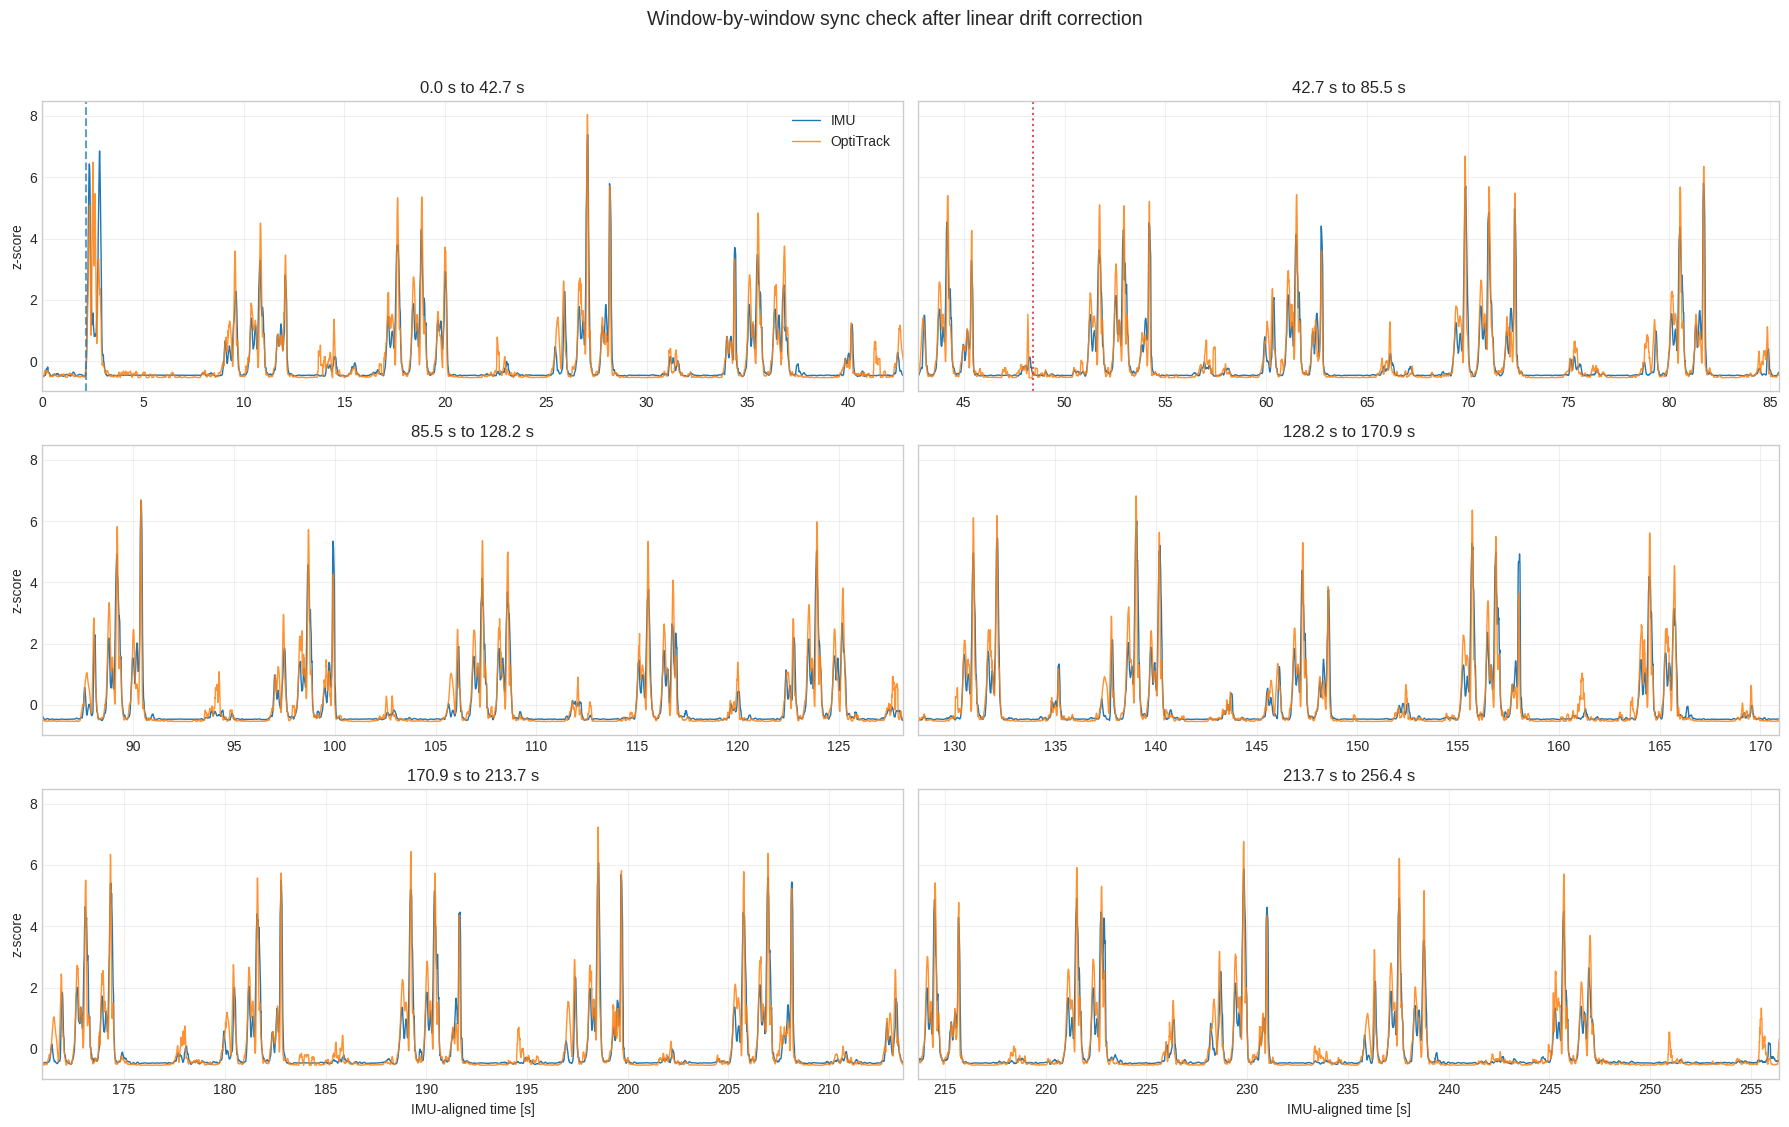

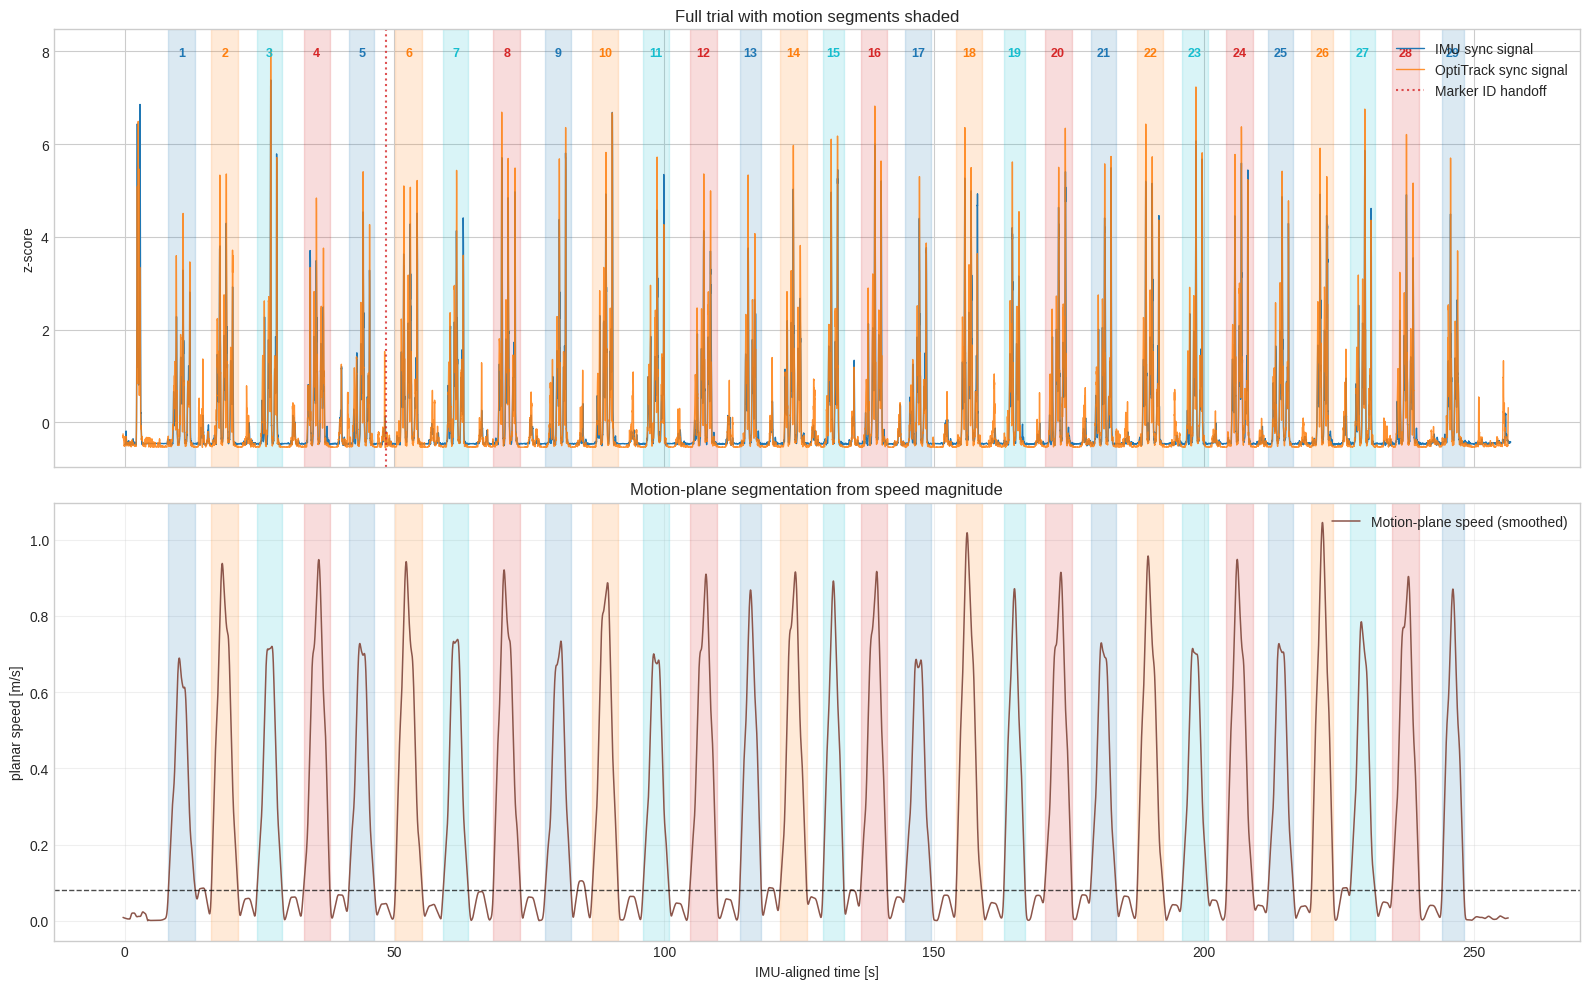

In [4]:
common_start = max(float(imu['imu_time'].min()), float(opti_ankle['time_synced_linear'].min()))
common_end = min(float(imu['imu_time'].max()), float(opti_ankle['time_synced_linear'].max()))

imu_time = imu['imu_time'].to_numpy()
imu_sync_z = safe_zscore(imu['imu_sync_signal'].to_numpy())
opti_sync_z = safe_zscore(opti_ankle['opti_sync_signal'].fillna(0).to_numpy())

opti_before_on_imu = np.interp(
    imu_time,
    opti_ankle['opti_time'].to_numpy(),
    opti_sync_z,
    left=np.nan,
    right=np.nan,
)
opti_const_on_imu = np.interp(
    imu_time,
    opti_ankle['time_synced_const'].to_numpy(),
    opti_sync_z,
    left=np.nan,
    right=np.nan,
)
opti_linear_on_imu = np.interp(
    imu_time,
    opti_ankle['time_synced_linear'].to_numpy(),
    opti_sync_z,
    left=np.nan,
    right=np.nan,
)

overlap_mask = (imu_time >= common_start) & (imu_time <= common_end)
corr_before = overlap_corr(imu_sync_z[overlap_mask], opti_before_on_imu[overlap_mask])
corr_const = overlap_corr(imu_sync_z[overlap_mask], opti_const_on_imu[overlap_mask])
corr_linear = overlap_corr(imu_sync_z[overlap_mask], opti_linear_on_imu[overlap_mask])

handoff_time_const = None
handoff_time_linear = None
if switch_log:
    handoff_frame = switch_log[0]['first_new_frame']
    handoff_const_match = opti_ankle.loc[opti_ankle['frame'] == handoff_frame, 'time_synced_const']
    handoff_linear_match = opti_ankle.loc[opti_ankle['frame'] == handoff_frame, 'time_synced_linear']
    if not handoff_const_match.empty:
        handoff_time_const = float(handoff_const_match.iloc[0])
    if not handoff_linear_match.empty:
        handoff_time_linear = float(handoff_linear_match.iloc[0])

print(f'Common overlap on IMU timeline: {common_start:.3f} s to {common_end:.3f} s')
print(f'Full-trial correlation before sync:          {corr_before:.4f}')
print(f'Full-trial correlation after constant shift: {corr_const:.4f}')
print(f'Full-trial correlation after linear sync:    {corr_linear:.4f}')
if handoff_time_linear is not None:
    print(f'Marker handoff on IMU timeline:              {handoff_time_linear:.3f} s')

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=False)

axes[0].plot(imu['imu_time'], imu_sync_z, label='IMU sync signal', linewidth=1.0)
axes[0].plot(opti_ankle['opti_time'], opti_sync_z, label='OptiTrack sync signal', linewidth=1.0, alpha=0.85)
axes[0].axvline(float(imu.loc[imu_onset_idx, 'imu_time']), color='tab:blue', linestyle='--', alpha=0.7, label='Swing onset')
axes[0].axvline(float(opti_ankle.loc[opti_onset_idx, 'opti_time']), color='tab:orange', linestyle='--', alpha=0.7, label='OptiTrack onset')
axes[0].set_xlim(0, max(float(imu['imu_time'].max()), float(opti_ankle['opti_time'].max())))
axes[0].set_title(f'Full-trial overview before sync | corr={corr_before:.4f}')
axes[0].set_ylabel('z-score')
axes[0].legend(loc='upper right')

axes[1].plot(imu['imu_time'], imu_sync_z, label='IMU sync signal', linewidth=1.0)
axes[1].plot(opti_ankle['time_synced_const'], opti_sync_z, label='OptiTrack after constant offset', linewidth=1.0, alpha=0.85)
axes[1].axvline(float(imu.loc[imu_onset_idx, 'imu_time']), color='tab:blue', linestyle='--', alpha=0.7, label='Swing onset')
if handoff_time_const is not None:
    axes[1].axvline(handoff_time_const, color='tab:red', linestyle=':', alpha=0.8, label='Marker ID handoff')
axes[1].set_xlim(common_start, common_end)
axes[1].set_title(f'After constant offset only | corr={corr_const:.4f}')
axes[1].set_ylabel('z-score')
axes[1].legend(loc='upper right')

axes[2].plot(imu['imu_time'], imu_sync_z, label='IMU sync signal', linewidth=1.0)
axes[2].plot(opti_ankle['time_synced_linear'], opti_sync_z, label='OptiTrack after linear drift correction', linewidth=1.0, alpha=0.85)
axes[2].axvline(float(imu.loc[imu_onset_idx, 'imu_time']), color='tab:blue', linestyle='--', alpha=0.7, label='Swing onset')
if handoff_time_linear is not None:
    axes[2].axvline(handoff_time_linear, color='tab:red', linestyle=':', alpha=0.8, label='Marker ID handoff')
axes[2].set_xlim(common_start, common_end)
axes[2].set_title(f'After linear drift correction | corr={corr_linear:.4f}')
axes[2].set_xlabel('IMU-aligned time [s]')
axes[2].set_ylabel('z-score')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

if not local_lag_df.empty:
    fit_x = np.linspace(local_lag_df['center_time_s'].min(), local_lag_df['center_time_s'].max(), 300)
    fit_y = drift_slope_sec_per_sec * fit_x + drift_intercept_sec

    fig, ax = plt.subplots(1, 1, figsize=(15, 5))
    ax.plot(
        local_lag_df['center_time_s'],
        local_lag_df['residual_lag_sec'],
        'o-',
        label='Residual lag after constant offset',
    )
    ax.plot(fit_x, fit_y, '--', linewidth=2.0, label=f'Linear fit ({LINEAR_FIT_METHOD})')
    if not local_lag_df_linear.empty:
        ax.plot(
            local_lag_df_linear['center_time_s'],
            local_lag_df_linear['residual_lag_sec'],
            'o-',
            label='Residual lag after linear correction',
        )
    ax.axhline(0.0, color='black', linewidth=1.0, alpha=0.5)
    ax.set_title('Windowed residual lag across the full trial')
    ax.set_xlabel('Window center on IMU timeline [s]')
    ax.set_ylabel('Residual lag [s]')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

window_count = 6
window_edges = np.linspace(common_start, common_end, window_count + 1)
fig, axes = plt.subplots(3, 2, figsize=(18, 11), sharey=True)
axes = axes.ravel()

for ax, start, end in zip(axes, window_edges[:-1], window_edges[1:]):
    imu_mask = (imu_time >= start) & (imu_time <= end)
    opti_mask = (opti_ankle['time_synced_linear'] >= start) & (opti_ankle['time_synced_linear'] <= end)
    ax.plot(imu_time[imu_mask], imu_sync_z[imu_mask], label='IMU', linewidth=1.0)
    ax.plot(opti_ankle.loc[opti_mask, 'time_synced_linear'], opti_sync_z[opti_mask], label='OptiTrack', linewidth=1.0, alpha=0.85)
    if start <= float(imu.loc[imu_onset_idx, 'imu_time']) <= end:
        ax.axvline(float(imu.loc[imu_onset_idx, 'imu_time']), color='tab:blue', linestyle='--', alpha=0.7)
    if handoff_time_linear is not None and start <= handoff_time_linear <= end:
        ax.axvline(handoff_time_linear, color='tab:red', linestyle=':', alpha=0.8)
    ax.set_xlim(start, end)
    ax.set_title(f'{start:.1f} s to {end:.1f} s')
    ax.grid(True, alpha=0.3)

axes[0].legend(loc='upper right')
for ax in axes[-2:]:
    ax.set_xlabel('IMU-aligned time [s]')
for ax in axes[::2]:
    ax.set_ylabel('z-score')

plt.suptitle('Window-by-window sync check after linear drift correction', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

if not segment_summary_df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

    axes[0].plot(imu['imu_time'], imu_sync_z, label='IMU sync signal', linewidth=1.0, color='tab:blue')
    axes[0].plot(
        opti_ankle['time_synced_to_imu'],
        opti_sync_z,
        label='OptiTrack sync signal',
        linewidth=1.0,
        alpha=0.85,
        color='tab:orange',
    )

    color_map = {
        'axis_1_positive': 'tab:blue',
        'axis_1_negative': 'tab:cyan',
        'axis_2_positive': 'tab:orange',
        'axis_2_negative': 'tab:red',
    }
    for segment in segment_summary_df.itertuples(index=False):
        color = color_map.get(segment.direction_label, 'tab:gray')
        axes[0].axvspan(segment.start_time_s, segment.end_time_s, color=color, alpha=0.16)
        axes[0].text(
            0.5 * (segment.start_time_s + segment.end_time_s),
            0.96,
            str(segment.segment_id),
            transform=axes[0].get_xaxis_transform(),
            ha='center',
            va='top',
            fontsize=9,
            color=color,
            weight='bold',
        )

    if handoff_time_linear is not None:
        axes[0].axvline(handoff_time_linear, color='tab:red', linestyle=':', alpha=0.8, label='Marker ID handoff')
    axes[0].set_ylabel('z-score')
    axes[0].set_title('Full trial with motion segments shaded')
    axes[0].legend(loc='upper right')

    axes[1].plot(
        opti_ankle['time_synced_to_imu'],
        opti_ankle['motion_plane_speed_smooth_mps'],
        linewidth=1.1,
        color='tab:brown',
        label='Motion-plane speed (smoothed)',
    )
    axes[1].axhline(SEGMENT_MIN_SPEED_MPS, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
    for segment in segment_summary_df.itertuples(index=False):
        color = color_map.get(segment.direction_label, 'tab:gray')
        axes[1].axvspan(segment.start_time_s, segment.end_time_s, color=color, alpha=0.16)
    axes[1].set_xlabel('IMU-aligned time [s]')
    axes[1].set_ylabel('planar speed [m/s]')
    axes[1].set_title('Motion-plane segmentation from speed magnitude')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()


In [5]:
imu_out = DATA_DIR / 'LOG00006_with_sync_signal.csv'
opti_out = DATA_DIR / 'Take 2026-03-24 05.20.13 PM_ankle_synced.csv'
summary_out = DATA_DIR / 'sync_summary.csv'
lag_out = DATA_DIR / 'sync_window_lags.csv'
segment_summary_out = DATA_DIR / 'straight_walk_segments_summary.csv'

lag_export = local_lag_df.rename(
    columns={
        'residual_lag_sec': 'residual_lag_const_sec',
        'corr': 'corr_const',
        'n_samples': 'n_samples_const',
    }
)
lag_export = lag_export.merge(
    local_lag_df_linear[['center_time_s', 'residual_lag_sec', 'corr', 'n_samples']].rename(
        columns={
            'residual_lag_sec': 'residual_lag_linear_sec',
            'corr': 'corr_linear',
            'n_samples': 'n_samples_linear',
        }
    ),
    on='center_time_s',
    how='outer',
)

SEGMENT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for old_segment_file in SEGMENT_OUTPUT_DIR.glob('segment_*_imu.csv'):
    old_segment_file.unlink()
for old_segment_file in SEGMENT_OUTPUT_DIR.glob('segment_*_opti.csv'):
    old_segment_file.unlink()

imu.to_csv(imu_out, index=False)
opti_ankle.to_csv(opti_out, index=False)
pd.DataFrame([summary]).to_csv(summary_out, index=False)
lag_export.to_csv(lag_out, index=False)
segment_summary_df.to_csv(segment_summary_out, index=False)

for segment in segment_summary_df.itertuples(index=False):
    segment_name = f"segment_{int(segment.segment_id):02d}_{segment.direction_label}"
    opti_seg = opti_ankle.loc[
        (opti_ankle[SEGMENT_TIME_COLUMN] >= segment.start_time_s)
        & (opti_ankle[SEGMENT_TIME_COLUMN] <= segment.end_time_s)
    ].copy()
    imu_seg = imu.loc[
        (imu['imu_time'] >= segment.start_time_s)
        & (imu['imu_time'] <= segment.end_time_s)
    ].copy()
    opti_seg.to_csv(SEGMENT_OUTPUT_DIR / f'{segment_name}_opti.csv', index=False)
    imu_seg.to_csv(SEGMENT_OUTPUT_DIR / f'{segment_name}_imu.csv', index=False)

print(f'Saved: {imu_out}')
print(f'Saved: {opti_out}')
print(f'Saved: {summary_out}')
print(f'Saved: {lag_out}')
print(f'Saved: {segment_summary_out}')
print(f'Saved segment files under: {SEGMENT_OUTPUT_DIR}')


Saved: /home/user/soccer_analysis/data/optitrack_imu/0324_17_20/LOG00006_with_sync_signal.csv
Saved: /home/user/soccer_analysis/data/optitrack_imu/0324_17_20/Take 2026-03-24 05.20.13 PM_ankle_synced.csv
Saved: /home/user/soccer_analysis/data/optitrack_imu/0324_17_20/sync_summary.csv
Saved: /home/user/soccer_analysis/data/optitrack_imu/0324_17_20/sync_window_lags.csv
Saved: /home/user/soccer_analysis/data/optitrack_imu/0324_17_20/straight_walk_segments_summary.csv
Saved segment files under: /home/user/soccer_analysis/data/optitrack_imu/0324_17_20/straight_walk_segments
